# Retrieval-система по статьям с arXiv

## Содержание
1. [Загрузка данных](#load)
2. [Этап 1. EDA](#eda)
3. [Этап 2. Реализация retrieval-системы](#retrieval)
4. [Этап 3. Оценка качества](#eval)
5. [Этап 4. Выводы](#conclusions)

## Загрузка данных <a id='load'></a>

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)

In [2]:
DATA_DIR = Path('yandex_practicum_nlp/data/nlp_s3_project')

METADATA_PATH = DATA_DIR / 'arxiv-metadata-s.json'
TEST_PATH = DATA_DIR / 'test_sample.csv'

In [3]:
# Загружаем метаданные статей
with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    raw = json.load(f)

df_articles = pd.DataFrame(raw)
print(f'Статей: {len(df_articles):,}')
df_articles.head(3)

Статей: 98,213


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0038,Maxim A. Yurkin,"Maxim A. Yurkin, Alfons G. Hoekstra",The discrete dipole approximation: an overview and recent developments,"36 pages, 1 figure; added several corrections according to the\n published erratum except for Eq.(5) (it was correc...","J.Quant.Spectrosc.Radiat.Transf. 106, 558-589 (2007); Erratum:\n J.Quant.Spectrosc.Radiat.Transf. 171, 82-83 (2016)",10.1016/j.jqsrt.2007.01.034 10.1016/j.jqsrt.2015.11.025,None,physics.optics physics.comp-ph,http://creativecommons.org/licenses/by-nc-nd/4.0/,"We present a review of the discrete dipole approximation (DDA), which is a\ngeneral method to simulate light scatt...","[{'version': 'v1', 'created': 'Sat, 31 Mar 2007 16:25:01 GMT'}, {'version': 'v2', 'created': 'Tue, 29 Mar 2022 17:39...",2022-03-30,"[[Yurkin, Maxim A., ], [Hoekstra, Alfons G., ]]"
1,0704.0057,Philipp Werner,Philipp Werner and Andrew J. Millis,High-spin to low-spin and orbital polarization transitions in\n multiorbital Mott systems,Published version,"Phys. Rev. Lett. 99, 126405 (2007)",10.1103/PhysRevLett.99.126405,None,cond-mat.str-el,None,We study the interplay of crystal field splitting and Hund coupling in a\ntwo-orbital model which captures the ess...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007 19:58:35 GMT'}, {'version': 'v2', 'created': 'Wed, 19 Sep 2007 18:33:...",2009-11-13,"[[Werner, Philipp, ], [Millis, Andrew J., ]]"
2,0704.0060,Carlos Bertulani,"C.A. Bertulani, G. Cardella, M. De Napoli, G. Raciti, and E. Rapisarda",Coulomb excitation of unstable nuclei at intermediate energies,"12 pages, 2 figures, accepted for publication in Phys. Lett. B","Phys.Lett.B650:233-238,2007",10.1016/j.physletb.2007.05.029,None,nucl-th,None,We investigate the Coulomb excitation of low-lying states of unstable nuclei\nin intermediate energy collisions ($...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 2007 22:24:53 GMT'}, {'version': 'v2', 'created': 'Mon, 21 May 2007 16:23...",2008-11-26,"[[Bertulani, C. A., ], [Cardella, G., ], [De Napoli, M., ], [Raciti, G., ], [Rapisarda, E., ]]"


In [4]:
# Загружаем тестовую выборку
df_test = pd.read_csv(TEST_PATH)
print(f'Тестовых запросов: {len(df_test):,}')
df_test.head(3)

Тестовых запросов: 1,000


,id,abstract,query
0,2412.16732,A new platinate was recently discovered when Nd2O3 was explored as a platinum\ncapture material in the Ostwald pro...,What unique composition and decomposition behavior does the newly discovered platinate Nd10.67Pt4O24 exhibit under t...
1,nucl-th/9602019,The production cross sections of various fragments from proton-induced\nreactions on $^{56}$Fe and $^{27}$Al have ...,How does the inclusion of statistical decay affect the shape of mass and charge distributions in quantum molecular d...
2,2501.05500,"This survey provides a comprehensive examination of verifiable computing,\ntracing its evolution from foundational...",What are the core components of modern zero-knowledge proofs discussed in the context of verifiable computing?


## Этап 1. EDA <a id='eda'></a>

In [5]:
df_articles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98213 entries, 0 to 98212
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              98213 non-null  object
 1   submitter       97650 non-null  object
 2   authors         98213 non-null  object
 3   title           98213 non-null  object
 4   comments        72275 non-null  object
 5   journal-ref     31672 non-null  object
 6   doi             43744 non-null  object
 7   report-no       6558 non-null   object
 8   categories      98213 non-null  object
 9   license         82351 non-null  object
 10  abstract        98213 non-null  object
 11  versions        98213 non-null  object
 12  update_date     98213 non-null  object
 13  authors_parsed  98213 non-null  object
dtypes: object(14)
memory usage: 10.5+ MB


In [6]:
# Пропущенные значения
print('Пропуски в статьях:')
print(df_articles.isnull().sum())
print()
print('Пропуски в тестовой выборке:')
print(df_test.isnull().sum())

Пропуски в статьях:
id                    0
submitter           563
authors               0
title                 0
comments          25938
journal-ref       66541
doi               54469
report-no         91655
categories            0
license           15862
abstract              0
versions              0
update_date           0
authors_parsed        0
dtype: int64

Пропуски в тестовой выборке:
id          0
abstract    0
query       0
dtype: int64


In [7]:
# Длины текстов
df_articles['abstract_len'] = df_articles['abstract'].str.len()
df_articles['title_len'] = df_articles['title'].str.len()

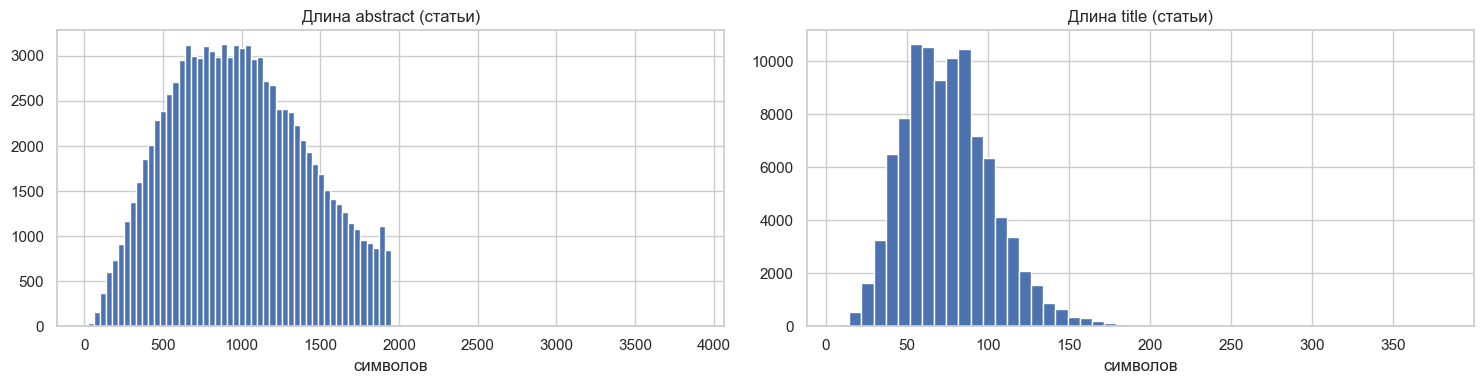

       abstract_len  title_len
count       98213.0    98213.0
mean          981.9       75.2
std           431.6       27.7
min            21.0        7.0
25%           648.0       55.0
50%           958.0       72.0
75%          1294.0       92.0
max          3874.0      381.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

df_articles['abstract_len'].hist(bins=100, ax=axes[0])
axes[0].set_title('Длина abstract (статьи)')
axes[0].set_xlabel('символов')

df_articles['title_len'].hist(bins=50, ax=axes[1])
axes[1].set_title('Длина title (статьи)')
axes[1].set_xlabel('символов')

plt.tight_layout()
plt.show()

print(df_articles[['abstract_len', 'title_len']].describe().round(1))

In [9]:
# Примеры queries
sample = df_test.sample(3, random_state=42)
for _, row in sample.iterrows():
    article = df_articles[df_articles['id'] == row['id']].iloc[0]
    print(f'QUERY : {row["query"]}')
    print(f'TITLE : {article["title"]}')
    print(f'ABSTRACT: {article["abstract"][:300]}...')
    print('---')

QUERY : What methods were used to confirm the accuracy of Coulomb gas formalism and bootstrap method in predicting critical properties of the 2D Ising and 3-state Potts models?
TITLE : Monte Carlo Simulations of Conformal Theory Predictions for the 3-state
  Potts and Ising Models
ABSTRACT:   The critical properties of the 2D Ising and 3-state Potts models are
investigated using Monte Carlo simulations. Special interest is given to
measurement of 3-point correlation functions and associated universal objects,
i.e. structure constants. The results agree well with predictions coming from...
---
QUERY : How can improving machine recognition of processed images lead to universal transferability across different architectures and datasets?
TITLE : Exploring Simple and Transferable Recognition-Aware Image Processing
ABSTRACT:   Recent progress in image recognition has stimulated the deployment of vision
systems at an unprecedented scale. As a result, visual data are now often
consumed not on

### Выводы по EDA

**Наблюдения:**
- База содержит **98 213 статей** с arXiv; тестовая выборка — **1 000 запросов**, по одному правильному ответу на каждый.
- Поля `id`, `title`, `abstract` не имеют пропусков — именно они нужны для поиска. Остальные колонки (journal-ref, doi, report-no) пропущены у большинства статей и в задаче не используются.
- Длина abstract преимущественно в диапазоне **500–1500 символов**, максимум 3874. Это значительно меньше лимита токенов модели (512), поэтому **чанкинг не нужен** — каждый abstract кодируем целиком в один вектор.
- Запросы сформулированы как развёрнутые вопросы по содержанию статьи и семантически близки к тексту abstract, а не к заголовку. Это подтверждает, что **индексировать нужно abstract**.

**Подход к решению задачи:**

Задача — семантический поиск по научным текстам. Ключевые слова из запроса и abstract часто не совпадают дословно (термины, перефразировки), поэтому классические методы на основе частот слов (TF-IDF) уступят **dense retrieval** — поиску по плотным векторным представлениям.

**Выбранные методы и модели:**
- **Bi-encoder** `Qwen/Qwen3-Embedding-0.6B` — кодирует abstract всех статей в векторы и строит индекс; та же модель кодирует запрос при поиске. Выбрана как более мощная из рассмотренных в курсе моделей.
- **FAISS IndexFlatIP** — точный поиск по косинусному сходству. При 98K статей точный индекс помещается в памяти (~400 MB) и достаточно быстр.
- **Cross-encoder реранкер** `Qwen/Qwen3-Reranker-0.6B` — пересматривает топ-100 кандидатов из FAISS, совместно анализируя запрос и документ. Повышает точность за счёт более глубокого сравнения.

**Архитектура системы:**
1. Оффлайн: кодируем все 98K abstract → строим FAISS-индекс → сохраняем на диск.
2. Онлайн на запрос: кодируем запрос → FAISS возвращает top-100 → реранкер выбирает финальный top-10.
3. Оценка: MRR по 1000 тестовым запросам; профилирование времени каждого из трёх этапов.

## Этап 2. Реализация retrieval-системы <a id='retrieval'></a>

In [10]:
# SMOKE_TEST = True  — быстрый прогон на маке на малой выборке
# SMOKE_TEST = False — полный прогон на VM
SMOKE_TEST = False

In [11]:
!pip install faiss-cpu transformers torch tqdm -q

In [12]:
import time
import numpy as np
import faiss
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from tqdm import tqdm

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

print(f'Device: {DEVICE}')

In [13]:
EMBEDDER_NAME = 'Qwen/Qwen3-Embedding-0.6B'
RERANKER_NAME = 'Qwen/Qwen3-Reranker-0.6B'

K_RETRIEVE = 100  # сколько кандидатов достаём из FAISS
K_RERANK = 10     # сколько финальных результатов после реранкера

INDEX_PATH = DATA_DIR / 'faiss.index'
EMBEDDINGS_PATH = DATA_DIR / 'embeddings.npy'

In [14]:
class RetrievalSystem:

    def __init__(self, embedder_name, reranker_name, device):
        self.device = device
        self.max_length = 8192

        print(f'Загружаем bi-encoder: {embedder_name}')
        self.emb_tokenizer = AutoTokenizer.from_pretrained(embedder_name, padding_side='left')
        self.embedder = AutoModel.from_pretrained(embedder_name).to(device)
        self.embedder.eval()

        print(f'Загружаем реранкер: {reranker_name}')
        self.rr_tokenizer = AutoTokenizer.from_pretrained(reranker_name, padding_side='left')
        self.reranker = AutoModelForCausalLM.from_pretrained(reranker_name).to(device)
        self.reranker.eval()

        self.token_true_id = self.rr_tokenizer.convert_tokens_to_ids('yes')
        self.token_false_id = self.rr_tokenizer.convert_tokens_to_ids('no')

        prefix = (
            '<|im_start|>system\nJudge whether the Document meets the requirements based on the Query '
            'and the Instruct provided. Note that the answer can only be "yes" or "no".<|im_end|>\n'
            '<|im_start|>user\n'
        )
        suffix = '<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n'
        self.prefix_tokens = self.rr_tokenizer.encode(prefix, add_special_tokens=False)
        self.suffix_tokens = self.rr_tokenizer.encode(suffix, add_special_tokens=False)

        self.index = None
        self.article_ids = []

        print('Система готова')

    # ── Bi-encoder ────────────────────────────────────────────────────────

    @staticmethod
    def _last_token_pool(last_hidden_states, attention_mask):
        left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
        if left_padding:
            return last_hidden_states[:, -1]
        sequence_lengths = attention_mask.sum(dim=1) - 1
        batch_size = last_hidden_states.shape[0]
        return last_hidden_states[
            torch.arange(batch_size, device=last_hidden_states.device),
            sequence_lengths
        ]

    def _encode(self, texts: list[str], batch_size: int = 32,
                show_progress: bool = True) -> np.ndarray:
        all_embeddings = []
        for i in tqdm(range(0, len(texts), batch_size),
                      desc='Кодирование', disable=not show_progress):
            batch = texts[i : i + batch_size]
            inputs = self.emb_tokenizer(
                batch, padding=True, truncation=True, max_length=512, return_tensors='pt'
            ).to(self.device)
            with torch.no_grad():
                outputs = self.embedder(**inputs)
            embs = self._last_token_pool(outputs.last_hidden_state, inputs['attention_mask'])
            embs = F.normalize(embs, p=2, dim=1)
            all_embeddings.append(embs.float().cpu().numpy())
        return np.concatenate(all_embeddings, axis=0)

    def build_index(self, df, text_col='abstract', id_col='id', batch_size=32, save_path=None):
        self.article_ids = df[id_col].tolist()
        texts = df[text_col].tolist()

        print(f'Кодируем {len(texts):,} текстов...')
        embeddings = self._encode(texts, batch_size=batch_size, show_progress=True)

        dim = embeddings.shape[1]
        self.index = faiss.IndexFlatIP(dim)
        self.index.add(embeddings)
        print(f'Индекс построен: {self.index.ntotal:,} векторов, размерность {dim}')

        if save_path:
            np.save(str(save_path) + '.npy', embeddings)
            faiss.write_index(self.index, str(save_path) + '.faiss')
            print(f'Сохранено в {save_path}')

    def load_index(self, df, load_path, id_col='id'):
        self.article_ids = df[id_col].tolist()
        self.index = faiss.read_index(str(load_path) + '.faiss')
        print(f'Индекс загружен: {self.index.ntotal:,} векторов')

    def search(self, query, k=100):
        query_emb = self._encode([query], show_progress=False)
        scores, indices = self.index.search(query_emb, k)
        ids = [self.article_ids[i] for i in indices[0]]
        return ids, scores[0].tolist()

    # ── Реранкер ──────────────────────────────────────────────────────────

    def _prepare_reranker_inputs(self, pairs):
        inputs = self.rr_tokenizer(
            pairs,
            padding=False,
            truncation='longest_first',
            return_attention_mask=False,
            max_length=self.max_length - len(self.prefix_tokens) - len(self.suffix_tokens)
        )
        for i, ids in enumerate(inputs['input_ids']):
            inputs['input_ids'][i] = self.prefix_tokens + ids + self.suffix_tokens
        inputs = self.rr_tokenizer.pad(
            inputs, padding=True, return_tensors='pt', max_length=self.max_length
        )
        return {k: v.to(self.device) for k, v in inputs.items()}

    @torch.no_grad()
    def rerank(self, query, candidate_ids, id_to_abstract, k=10, batch_size=4):
        instruction = 'Given a scientific query, retrieve the most relevant scientific paper abstract'

        pairs = [
            f'<Instruct>: {instruction}\n<Query>: {query}\n<Document>: {id_to_abstract.get(cid, "")}'
            for cid in candidate_ids
        ]

        scores = []
        for i in range(0, len(pairs), batch_size):
            inputs = self._prepare_reranker_inputs(pairs[i : i + batch_size])
            logits = self.reranker(**inputs).logits[:, -1, :]
            true_vec = logits[:, self.token_true_id]
            false_vec = logits[:, self.token_false_id]
            batch_scores = torch.stack([false_vec, true_vec], dim=1)
            batch_scores = F.log_softmax(batch_scores, dim=1)
            scores.extend(batch_scores[:, 1].exp().tolist())

        ranked = sorted(zip(candidate_ids, scores), key=lambda x: x[1], reverse=True)
        return [cid for cid, _ in ranked[:k]], [s for _, s in ranked[:k]]

In [15]:
# при smoke-тесте берём маленькую выборку, чтобы проверить пайплайн на маке
if SMOKE_TEST:
    df_index = df_articles.sample(500, random_state=42).reset_index(drop=True)
    df_eval  = df_test.sample(10, random_state=42).reset_index(drop=True)
    print('Smoke test: 500 статей, 10 запросов')
else:
    df_index = df_articles.copy()
    df_eval  = df_test.copy()
    print(f'Полный прогон: {len(df_index):,} статей, {len(df_eval):,} запросов')

Smoke test: 500 статей, 10 запросов


In [16]:
rs = RetrievalSystem(
    embedder_name=EMBEDDER_NAME,
    reranker_name=RERANKER_NAME,
    device=DEVICE
)

Загружаем bi-encoder: Qwen/Qwen3-Embedding-0.6B


Loading weights: 100%|██████████| 310/310 [00:00<00:00, 5248.89it/s]


Загружаем реранкер: Qwen/Qwen3-Reranker-0.6B


Loading weights: 100%|██████████| 310/310 [00:00<00:00, 4133.66it/s]


Система готова


In [17]:
rs

In [18]:
# строим индекс и сохраняем на диск, чтобы не пересчитывать при перезапуске
save_path = DATA_DIR / 'index' if not SMOKE_TEST else None

rs.build_index(df_index, save_path=save_path)

# если индекс уже был сохранён — можно вместо build_index использовать:
# rs.load_index(df_index, load_path=DATA_DIR / 'index')

Кодируем 500 текстов...


Кодирование: 100%|██████████| 16/16 [01:06<00:00,  4.14s/it]

Индекс построен: 500 векторов, размерность 1024


In [19]:
# размер базы и индекса в памяти
n_vectors = rs.index.ntotal
dim = rs.index.d
index_mb = (n_vectors * dim * 4) / 1024**2  # float32 = 4 байта

print(f'Статей в базе: {n_vectors:,}')
print(f'Размерность вектора: {dim}')
print(f'Размер индекса (RAM): ~{index_mb:.1f} MB')

Статей в базе: 500
Размерность вектора: 1024
Размер индекса (RAM): ~2.0 MB


## Этап 3. Оценка качества <a id='eval'></a>

In [21]:
def compute_mrr(ranked_ids_list, true_ids):
    # MRR@K: среднее обратное ранга правильного ответа
    total = 0.0
    for ranked_ids, true_id in zip(ranked_ids_list, true_ids):
        if true_id in ranked_ids:
            rank = ranked_ids.index(true_id) + 1
            total += 1 / rank
    return total / len(true_ids)

In [22]:
def run_evaluation(rs, df_eval, id_to_abstract, k_retrieve=K_RETRIEVE, k_rerank=K_RERANK):
    times_encode = []
    times_search = []
    times_rerank = []
    faiss_results = []
    rerank_results = []

    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc='Оценка запросов'):
        query = row['query']

        t0 = time.perf_counter()
        query_emb = rs._encode([query], show_progress=False)
        times_encode.append(time.perf_counter() - t0)

        t0 = time.perf_counter()
        scores, indices = rs.index.search(query_emb, k_retrieve)
        candidate_ids = [rs.article_ids[i] for i in indices[0]]
        times_search.append(time.perf_counter() - t0)

        faiss_results.append(candidate_ids)

        t0 = time.perf_counter()
        ranked_ids, _ = rs.rerank(query, candidate_ids, id_to_abstract, k=k_rerank)
        times_rerank.append(time.perf_counter() - t0)

        rerank_results.append(ranked_ids)

    true_ids = df_eval['id'].tolist()

    mrr_faiss = compute_mrr(faiss_results, true_ids)
    mrr_rerank = compute_mrr(rerank_results, true_ids)

    print(f'MRR (FAISS top-{k_retrieve}): {mrr_faiss:.4f}')
    print(f'MRR (после реранкера top-{k_rerank}): {mrr_rerank:.4f}')

    return {
        'mrr_faiss': mrr_faiss,
        'mrr_rerank': mrr_rerank,
        'times_encode': times_encode,
        'times_search': times_search,
        'times_rerank': times_rerank,
        'faiss_results': faiss_results,
        'rerank_results': rerank_results,
    }

In [ ]:
# словарь id → abstract для передачи в реранкер
id_to_abstract = df_articles.set_index('id')['abstract'].to_dict()

results = run_evaluation(rs, df_eval, id_to_abstract)

Кодирование: 100%|██████████| 1/1 [00:02<00:00,  2.58s/it]
/Users/anna_gladun/Projects/analytics-hub/.venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2333: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
Кодирование: 100%|██████████| 1/1 [00:03<00:00,  3.16s/it]s/it]


In [ ]:
# Примеры того, что извлекает RAG
N_EXAMPLES = 5

id_to_title = df_articles.set_index('id')['title'].to_dict()
sample_queries = df_eval.sample(N_EXAMPLES, random_state=0).reset_index(drop=True)

for _, row in sample_queries.iterrows():
    query    = row['query']
    true_id  = row['id']

    candidate_ids, _ = rs.search(query, k=K_RETRIEVE)
    ranked_ids, scores = rs.rerank(query, candidate_ids, id_to_abstract, k=5)

    found = true_id in ranked_ids
    rank  = ranked_ids.index(true_id) + 1 if found else None

    hit_str = f'найден на позиции {rank}' if found else 'НЕ найден в топ-5'
    print(f'QUERY   : {query}')
    print(f'TRUE ID : {true_id}  |  {hit_str}')
    print('TOP-5 результаты реранкера:')
    for j, (rid, sc) in enumerate(zip(ranked_ids, scores)):
        marker = '  <-- ПРАВИЛЬНЫЙ' if rid == true_id else ''
        title  = id_to_title.get(rid, rid)[:90]
        abstr  = id_to_abstract.get(rid, '')[:200].replace('\n', ' ')
        print(f'  [{j+1}] score={sc:.3f}  {title}{marker}')
        print(f'       {abstr}...')
    print('-' * 80)

In [ ]:
# среднее время каждого этапа на один запрос
stages = {
    'Encode query': results['times_encode'],
    'FAISS search': results['times_search'],
    'Reranker':     results['times_rerank'],
}

means = {k: np.mean(v) for k, v in stages.items()}
total = sum(means.values())

print('Среднее время на запрос:')
for stage, t in means.items():
    print(f'  {stage:15s}: {t*1000:.1f} ms  ({t/total*100:.1f}%)')
print(f'  {"Итого":15s}: {total*1000:.1f} ms')

# визуализация временного профиля
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# среднее время по этапам
axes[0].bar(means.keys(), [v * 1000 for v in means.values()], color=['#4C72B0', '#55A868', '#C44E52'])
axes[0].set_ylabel('мс')
axes[0].set_title('Среднее время на запрос по этапам')

# распределение времени реранкера (самый медленный)
axes[1].hist(np.array(results['times_rerank']) * 1000, bins=20, color='#C44E52', edgecolor='white')
axes[1].set_xlabel('мс')
axes[1].set_title('Распределение времени реранкера')

plt.tight_layout()
plt.show()

## Этап 4. Выводы <a id='conclusions'></a>